In [2]:
import pandas as pd 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering



In [3]:
df = pd.read_csv("../data/processed/clean_data_clustering.csv")

In [4]:
numeric_colones= [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
categoral_colones =[
    "gender",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]
pre = ColumnTransformer(
    transformers =[
        ('num',StandardScaler(),numeric_colones),
        ('cat',OneHotEncoder(handle_unknown="ignore"),categoral_colones)
    ]
)
X_prepared = pre.fit_transform(df)

2 => 0.25497156578666486
3 => 0.25703946813236117
4 => 0.25513425607183116
5 => 0.21684283840711516
6 => 0.2040509957986201
7 => 0.20999804540924047
8 => 0.17196596173503073
9 => 0.15662437389652284
10 => 0.15532765125947914


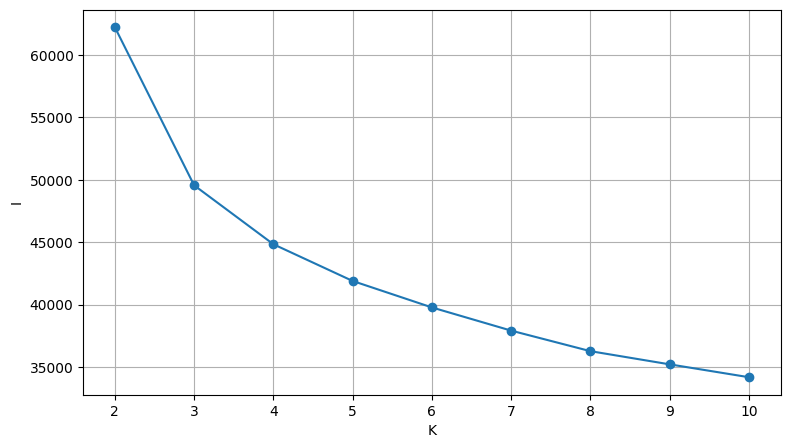

In [5]:
k_values = range(2, 11)
inertie = []
silhouette_scores =[]

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)

    score = silhouette_score(
        X_prepared,labels
    )
    silhouette_scores.append(score)
    inertie.append(model.inertia_)

    print(f"{k} => {score}")



plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertie, marker="o")

plt.xlabel("K")
plt.ylabel("I")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# k = 3

In [53]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

lable = dbscan.fit_predict(X_prepared)

df_dbscan = df.copy()
df_dbscan["Cluster"] = lable

# print(
#     df_dbscan["Cluster"].value_counts()
# )


silhouette_score_DBSCAN = silhouette_score(
    X_prepared,lable
)

print(silhouette_score_DBSCAN)
df_dbscan.to_csv("../data/test/db_scan.csv")

0.17281959520469609


In [55]:

agglomerative = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

agg_labels = agglomerative.fit_predict(X_prepared)

df_agg = df.copy()
df_agg["Cluster"] = agg_labels

# print(
#     df_agg["Cluster"]
#     .value_counts()
# )

silhouette_score_hiroque = silhouette_score(
    X_prepared,agg_labels
)
print(silhouette_score_hiroque)

0.23167292337248782
